In [200]:
import cv2
print(cv2.__version__)
import numpy as np
import matplotlib.pyplot as plt

4.11.0


In [201]:
# Read image
image = cv2.imread('coin.jpeg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

### QUESTION 1

#### PART A(Detect all coins in the image)

###### USING FIRST ORDER DERIVATIVE EDGE DETECTOR

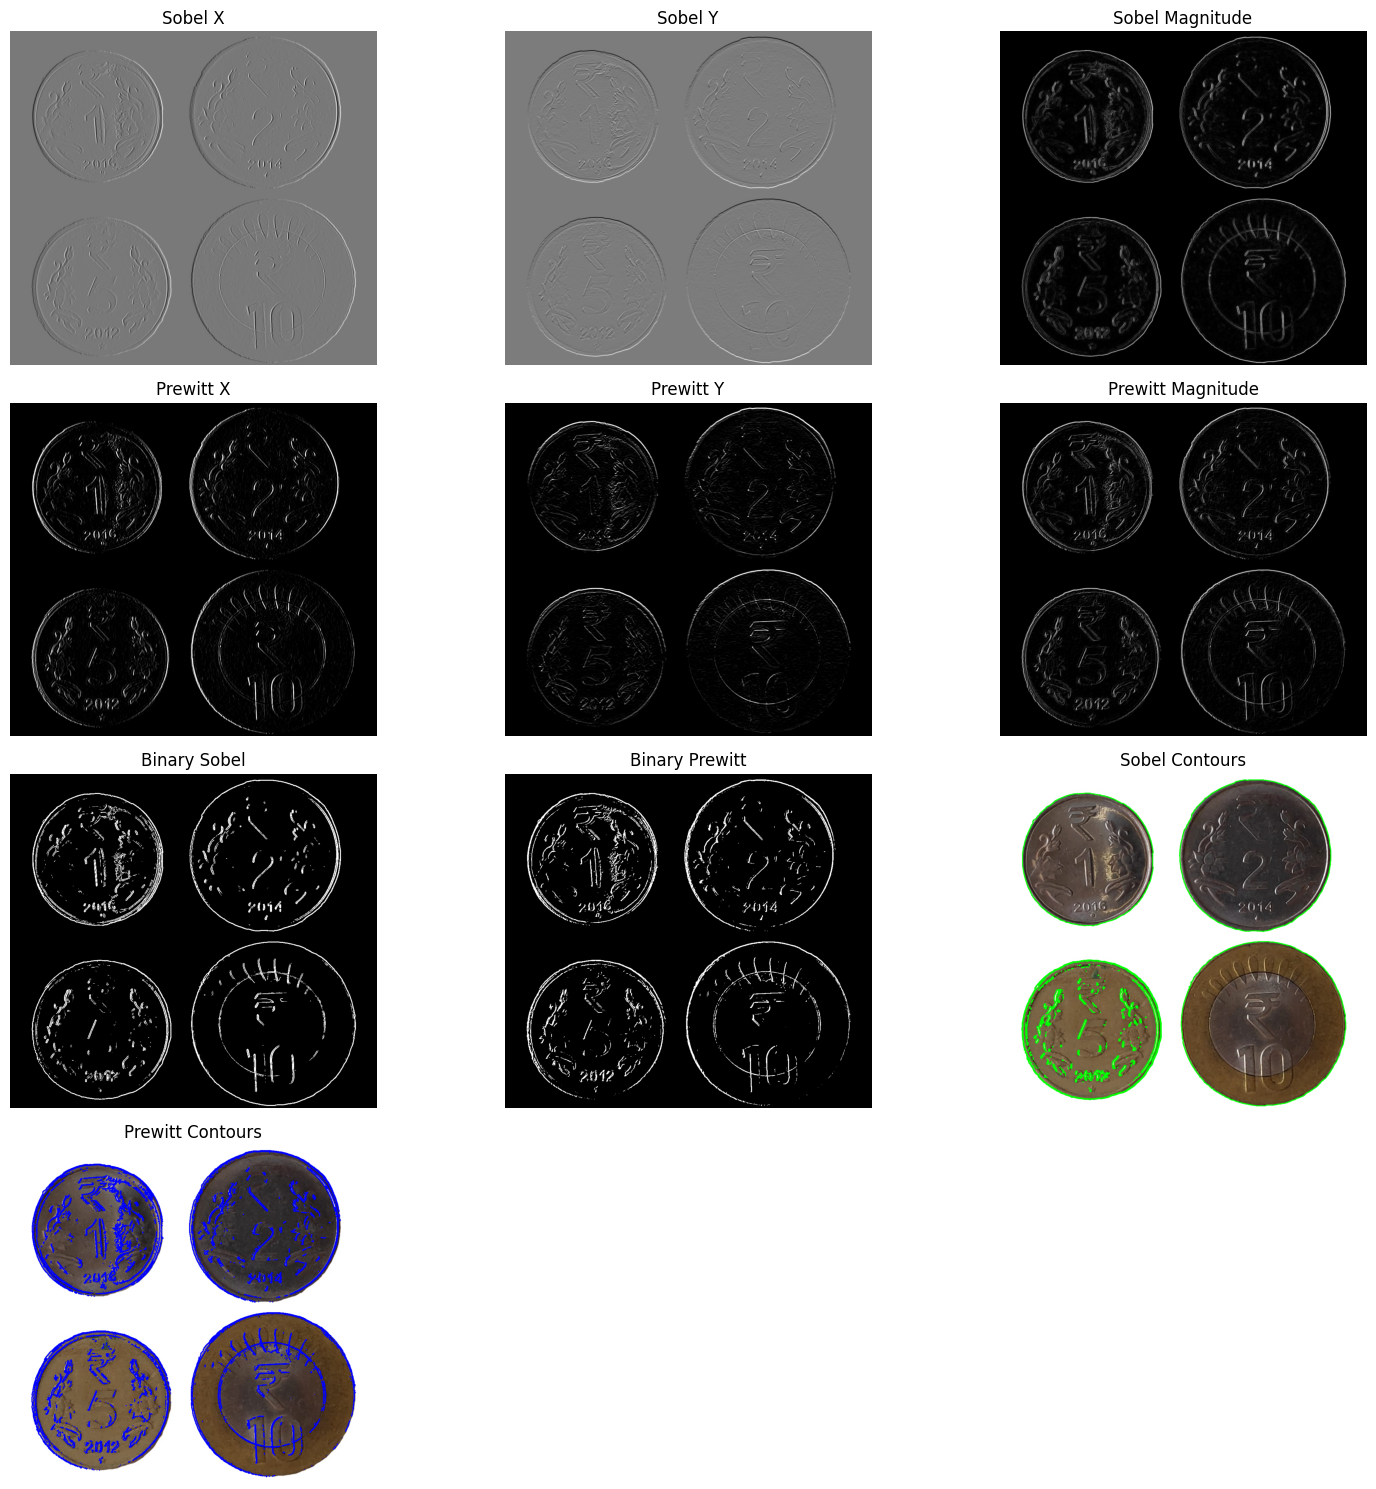

In [205]:
# Sobel Edge Detection
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)  # X gradient
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)  # Y gradient
sobel_edges = cv2.magnitude(sobel_x, sobel_y)

# Prewitt Edge Detection
prewitt_kernel_x = np.array([[1, 0, -1],
                              [1, 0, -1],
                              [1, 0, -1]], dtype=np.float32)

prewitt_kernel_y = np.array([[1, 1, 1],
                              [0, 0, 0],
                              [-1, -1, -1]], dtype=np.float32)

# Convolve the image with Prewitt kernels
prewitt_x = cv2.filter2D(gray, -1, prewitt_kernel_x)
prewitt_y = cv2.filter2D(gray, -1, prewitt_kernel_y)
prewitt_x = np.float64(prewitt_x)
prewitt_y = np.float64(prewitt_y)
# Compute Prewitt edge magnitude
prewitt_edges = cv2.magnitude(prewitt_x, prewitt_y)

# Normalize both Sobel and Prewitt results to 8-bit scale
sobel_edges = np.uint8(255 * sobel_edges / np.max(sobel_edges))
prewitt_edges = np.uint8(255 * prewitt_edges / np.max(prewitt_edges))

# Apply thresholding to create binary images for contour detection
_, binary_sobel = cv2.threshold(sobel_edges, 50, 255, cv2.THRESH_BINARY)
_, binary_prewitt = cv2.threshold(prewitt_edges, 50, 255, cv2.THRESH_BINARY)

# Find contours from the binary edge-detected images
contours_sobel, _ = cv2.findContours(binary_sobel, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_prewitt, _ = cv2.findContours(binary_prewitt, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Copy the original image for drawing contours
output_sobel = image.copy()
output_prewitt = image.copy()

# Draw the contours on the original image
cv2.drawContours(output_sobel, contours_sobel, -1, (0, 255, 0), 2)  # Green outline for Sobel
cv2.drawContours(output_prewitt, contours_prewitt, -1, (255, 0, 0), 2)  # Blue outline for Prewitt

# Display results
plt.figure(figsize=(15, 15))

# Show Sobel Edge Detection intermediate results
plt.subplot(4, 3, 1)
plt.imshow(sobel_x, cmap='gray')
plt.title("Sobel X")
plt.axis("off")

plt.subplot(4, 3, 2)
plt.imshow(sobel_y, cmap='gray')
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(4, 3, 3)
plt.imshow(sobel_edges, cmap='gray')
plt.title("Sobel Magnitude")
plt.axis("off")

# Show Prewitt Edge Detection intermediate results
plt.subplot(4, 3, 4)
plt.imshow(prewitt_x, cmap='gray')
plt.title("Prewitt X")
plt.axis("off")

plt.subplot(4, 3, 5)
plt.imshow(prewitt_y, cmap='gray')
plt.title("Prewitt Y")
plt.axis("off")

plt.subplot(4, 3, 6)
plt.imshow(prewitt_edges, cmap='gray')
plt.title("Prewitt Magnitude")
plt.axis("off")

# Show Binary Images for Sobel and Prewitt
plt.subplot(4, 3, 7)
plt.imshow(binary_sobel, cmap='gray')
plt.title("Binary Sobel")
plt.axis("off")

plt.subplot(4, 3, 8)
plt.imshow(binary_prewitt, cmap='gray')
plt.title("Binary Prewitt")
plt.axis("off")

# Show Final Output (Contours on Original Image)
plt.subplot(4, 3, 9)
output_sobel_rgb = cv2.cvtColor(output_sobel, cv2.COLOR_BGR2RGB)
plt.imshow(output_sobel_rgb)
plt.title("Sobel Contours")
plt.axis("off")

# Show Prewitt Contours on Original Image
plt.subplot(4, 3, 10)
output_prewitt_rgb = cv2.cvtColor(output_prewitt, cv2.COLOR_BGR2RGB)
plt.imshow(output_prewitt_rgb)
plt.title("Prewitt Contours")
plt.axis("off")

plt.tight_layout()
plt.show()


##### CONCLUSION
###### Sobel is less sensitive to noise
###### Prewitt is more sensitive to noise
###### Sobel generally performs better when you want more accurate, less noisy edges, especially in the presence of noise.
###### Prewitt is generally used when you want simpler, faster computations and you are dealing with less noisy images 
###### Sobel X/Y might produce less extreme values or smoother gradients, which are more subtle, leading to gradual gray-scale variations.
###### Prewitt X/Y, by contrast, might produce a stronger contrast in its edge detections, where you have stark differences between edge and non-edge pixels, hence appearing as black and white.

#### USING  Marr-Hildreth EDGE DETECTOR

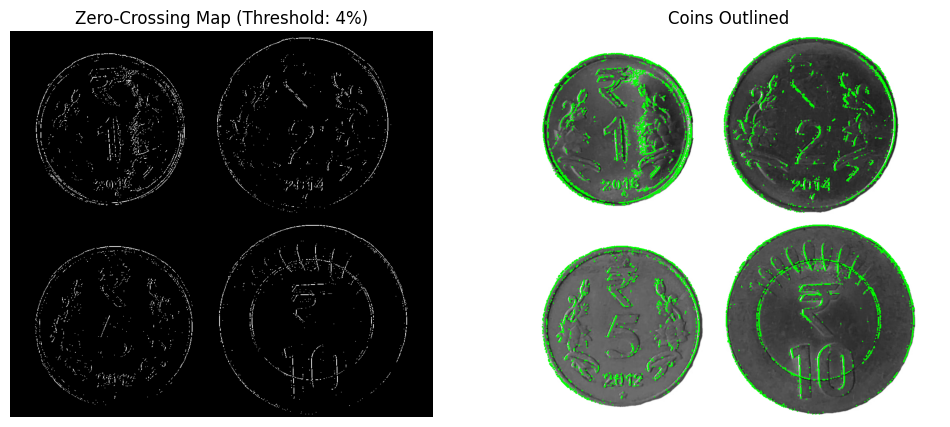

In [208]:
def apply_marr_hildreth(image_path, sigma, threshold_percent=4):
    # Load the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Apply Gaussian filter to smooth the image
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)

    # Compute the Laplacian of the Gaussian (LoG)
    laplacian = cv2.Laplacian(blurred, cv2.CV_64F)

    # Find the max value of the Laplacian
    max_laplacian_value = np.max(np.abs(laplacian))

    # Apply threshold: only consider zero-crossings greater than threshold percent of max value
    threshold_value = threshold_percent / 100.0 * max_laplacian_value

    # Zero-crossing detection: find places where the Laplacian changes signs
    zero_crossing = np.zeros_like(laplacian)
    
    # Apply the threshold for zero-crossing detection
    zero_crossing[1:-1, 1:-1] = (
        ((laplacian[1:-1, 1:-1] > threshold_value) & (laplacian[:-2, 1:-1] < -threshold_value)) |
        ((laplacian[1:-1, 1:-1] > threshold_value) & (laplacian[1:-1, :-2] < -threshold_value)) |
        ((laplacian[1:-1, 1:-1] < -threshold_value) & (laplacian[2:, 1:-1] > threshold_value)) |
        ((laplacian[1:-1, 1:-1] < -threshold_value) & (laplacian[1:-1, 2:] > threshold_value))
    ).astype(np.uint8) * 255

    return image, zero_crossing

def outline_coins(image, zero_crossing_image):
    # Convert zero_crossing_image to the correct type (8-bit unsigned integer) if necessary
    zero_crossing_image = cv2.convertScaleAbs(zero_crossing_image)

    # Find contours on the zero-crossing image
    contours, _ = cv2.findContours(zero_crossing_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Copy the original image to draw contours
    outlined_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    
    # Draw all contours (outline of detected coins)
    cv2.drawContours(outlined_image, contours, -1, (0, 255, 0), 2)  # Green color for the outlines

    return outlined_image

def main():
    image_path = 'coin.jpeg'  # Replace with your image path
    sigma = 1.0  # Standard deviation for the Gaussian kernel
    threshold_percent = 4  # 4% of the maximum value for zero-crossing threshold

    # Apply the Marr-Hildreth edge detector
    original_image, zero_crossing_image = apply_marr_hildreth(image_path, sigma, threshold_percent)

    # Outline the coins based on zero-crossing map
    outlined_image = outline_coins(original_image, zero_crossing_image)

    # Display the results
    plt.figure(figsize=(12, 6))
    
    # Display the zero-crossing map first
    plt.subplot(1, 2, 1)
    plt.title(f'Zero-Crossing Map (Threshold: {threshold_percent}%)')
    plt.imshow(zero_crossing_image, cmap='gray')
    plt.axis('off')

    # Display the original image with outlines
    plt.subplot(1, 2, 2)
    plt.title('Coins Outlined')
    plt.imshow(cv2.cvtColor(outlined_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()

if __name__ == "__main__":
    main()


##### CONCLUSION
###### broken edges are present 
###### one pixel thick edges
###### less error(get true edges)

#### USING CANNY EDGE DETECTOR

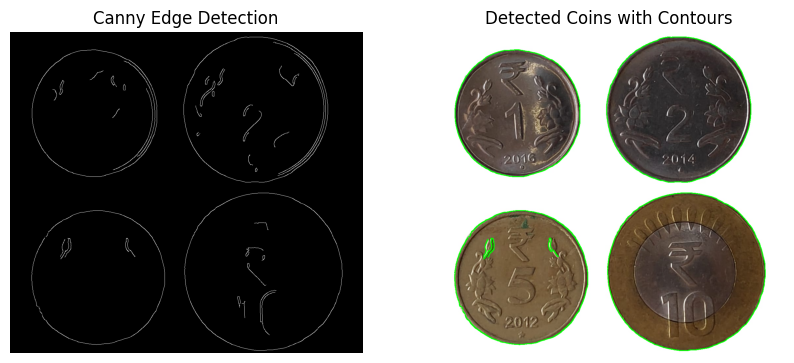

In [211]:
if image is None:
    print("Error: Image not found. Check the file path!")
    exit()

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(gray, (15, 15), 0)

# Use Canny Edge Detector
edges = cv2.Canny(blurred, 10, 150)

# Show the Canny Edge detection result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")

# Find contours of the coins
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on the original image
output = image.copy()
cv2.drawContours(output, contours, -1, (0, 255, 0), 2)  # Green outline

# Show the final outlined image
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
plt.subplot(1, 2, 2)
plt.imshow(output_rgb)
plt.title("Detected Coins with Contours")
plt.axis("off")

plt.show()

##### CONCLUSION 
###### less broken edges
###### one pixel thick edges
###### less error(get true edges)

#### Part B(Segmentation of Each Coin)

##### using Region Splitting and Merging

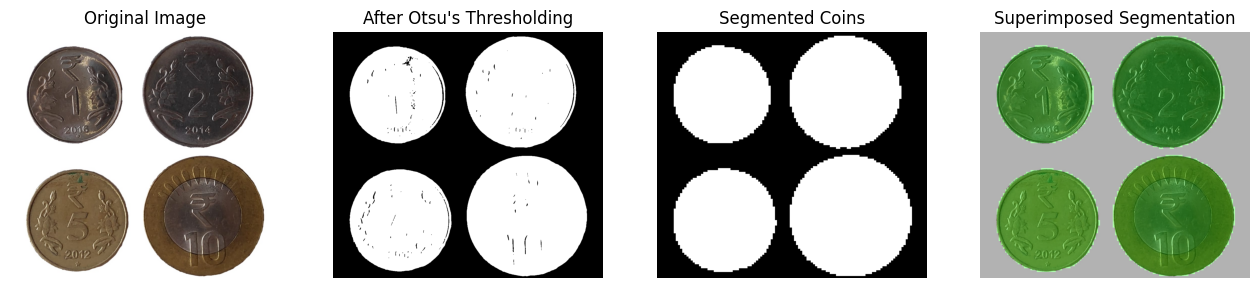

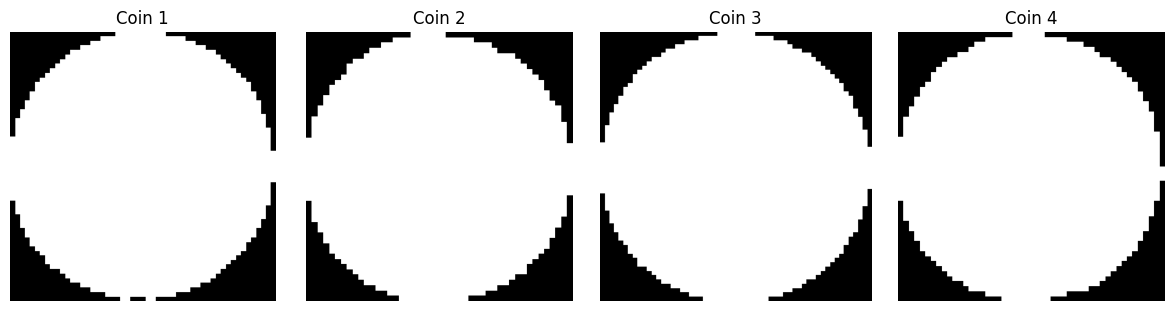

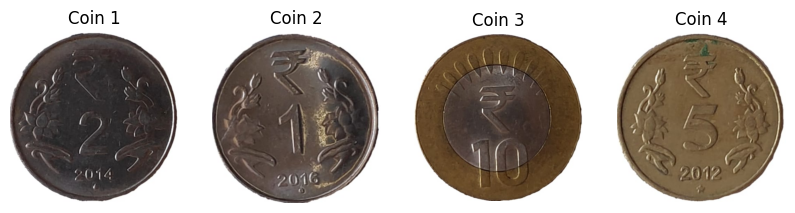

In [215]:
def region_splitting(image, threshold=90):
    """
    Perform region splitting based on intensity variance.
    """
    def split_region(x, y, w, h):
        """
        Recursively split the region if variance is high.
        """
        sub_img = image[y:y+h, x:x+w]
        variance = np.var(sub_img)
        
        if variance < threshold or min(w, h) <= 10:  # Stop splitting if variance is low or region is too small
            return [(x, y, w, h)]
        
        mid_w, mid_h = w // 2, h // 2
        regions = []
        regions += split_region(x, y, mid_w, mid_h)  # Top-left
        regions += split_region(x + mid_w, y, w - mid_w, mid_h)  # Top-right
        regions += split_region(x, y + mid_h, mid_w, h - mid_h)  # Bottom-left
        regions += split_region(x + mid_w, y + mid_h, w - mid_w, h - mid_h)  # Bottom-right
        
        return regions
    
    return split_region(0, 0, image.shape[1], image.shape[0])

def region_merging(image, regions, similarity_threshold=40):
    """
    Merge regions based on similarity (average intensity difference).
    """
    merged = np.zeros_like(image, dtype=np.uint8)
    
    for (x, y, w, h) in regions:
        mean_val = np.mean(image[y:y+h, x:x+w])
        if mean_val > similarity_threshold:
            merged[y:y+h, x:x+w] = 255  # Mark as foreground (coin)
    
    return merged

def extract_coins(segmented_image):
    """
    Extract individual coins from the segmented image using connected components.
    """
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(segmented_image, connectivity=8)
    
    extracted_coins = []
    for i in range(1, num_labels):  # Start from 1 to ignore the background
        x, y, w, h, area = stats[i]
        
        if area > 50:  # Ignore very small noise
            coin = segmented_image[y:y+h, x:x+w]  # Crop coin region
            extracted_coins.append(coin)

    return extracted_coins

# Load Image and Convert to Grayscale
original_image = cv2.imread("coin.jpeg")
gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to Reduce Noise
blurred = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Apply Otsu’s Thresholding
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Apply Region Splitting
regions = region_splitting(binary)

# Apply Region Merging
segmented_image = region_merging(binary, regions)

# Convert Segmented Image to Color Overlay
color_mask = np.zeros_like(original_image)
color_mask[segmented_image == 255] = [0, 255, 0]  # Green overlay for coins

# Superimpose Segmentation on Original Image
overlayed_image = cv2.addWeighted(original_image, 0.7, color_mask, 0.3, 0)

# Extract Coins
extracted_coins = extract_coins(segmented_image)

# Display Results
plt.figure(figsize=(16, 8))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(binary, cmap="gray")
plt.title("After Otsu's Thresholding")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(segmented_image, cmap="gray")
plt.title("Segmented Coins")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(overlayed_image, cv2.COLOR_BGR2RGB))
plt.title("Superimposed Segmentation")
plt.axis("off")

plt.show()

# Display Extracted Coins
plt.figure(figsize=(12, 6))
for idx, coin in enumerate(extracted_coins, 1):
    plt.subplot(2, 4, idx)  # Adjust grid size based on number of coins
    plt.imshow(coin, cmap="gray")
    plt.title(f"Coin {idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(segmented_image, connectivity=8)

extracted_coins = []
for i in range(1, num_labels):  # Start from 1 to ignore the background
    x, y, w, h, area = stats[i]

    if area > 50:  # Ignore small noise regions
        coin = original_image[y:y+h, x:x+w]  # Crop the coin region from the original image
        extracted_coins.append(coin)

# Display Extracted Coins
plt.figure(figsize=(10, 5))
for i, coin in enumerate(extracted_coins):
    plt.subplot(2, 4, i + 1)  # Adjust grid size as needed
    plt.imshow(cv2.cvtColor(coin, cv2.COLOR_BGR2RGB))
    plt.title(f"Coin {i+1}")
    plt.axis("off")

plt.show()


##### Using Watershed Algorithm for Image Segmentation

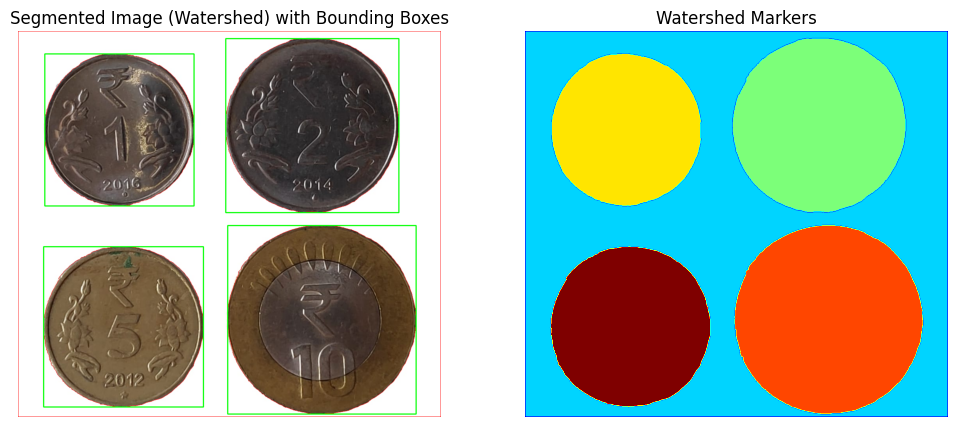

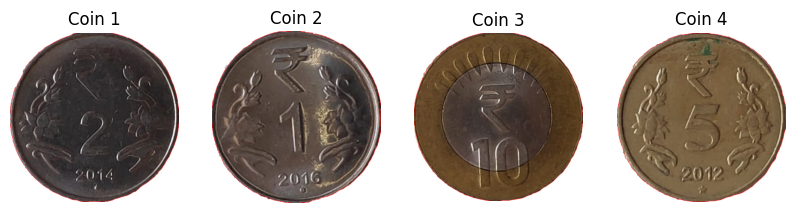

In [217]:
# Load image
image = cv2.imread("coin.jpeg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 1: Apply Gaussian Blur and Otsu’s Thresholding
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
_, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Step 2: Morphological Closing
kernel = np.ones((5,5), np.uint8)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=3)

# Step 3: Distance Transform & Sure Foreground
dist_transform = cv2.distanceTransform(closed, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.2 * dist_transform.max(), 255, 0)

# Step 4: Sure Background
sure_bg = cv2.dilate(closed, kernel, iterations=3)

# Step 5: Identify Unknown Region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Step 6: Assign Markers
num_labels, markers = cv2.connectedComponents(sure_fg)
markers += 1  # Background is now 1
markers[unknown == 255] = 0  # Mark unknown region as 0

# Step 7: Apply Watershed Algorithm
cv2.watershed(image, markers)
image[markers == -1] = [0, 0, 255]  # Mark boundaries in red

# Step 8: Extract Individual Coins Using Markers
extracted_coins = []
output = image.copy()

for i in range(2, num_labels + 1):  
    mask = np.where(markers == i, 255, 0).astype(np.uint8)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        coin = image[y:y+h, x:x+w]  # Extract coin
        extracted_coins.append(coin)

        # Draw bounding box
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Green Box

# Step 9: Display Segmented Image & Markers
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Segmented Image (Watershed) with Bounding Boxes")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(markers, cmap="jet")
plt.title("Watershed Markers")
plt.axis("off")

plt.show()

# Step 10: Display Extracted Coins Separately
plt.figure(figsize=(10, 5))
for i, coin in enumerate(extracted_coins):
    plt.subplot(2, 4, i + 1)  # Adjust grid size if needed
    plt.imshow(cv2.cvtColor(coin, cv2.COLOR_BGR2RGB))
    plt.title(f"Coin {i+1}")
    plt.axis("off")

plt.show()


##### conclusion
If coins are well-separated but the background has noise or slight intensity variations, Watershed may detect extra, unnecessary boundaries inside the coins or around minor details, making segmentation too fine-grained.
Watershed treats gradients as barriers.
Small changes in intensity can create many tiny regions.
For well-separated coins, Region Splitting & Merging avoids over-segmentation since it only splits where necessary based on variance.

#### PART C(Count the Total Number of Coins)

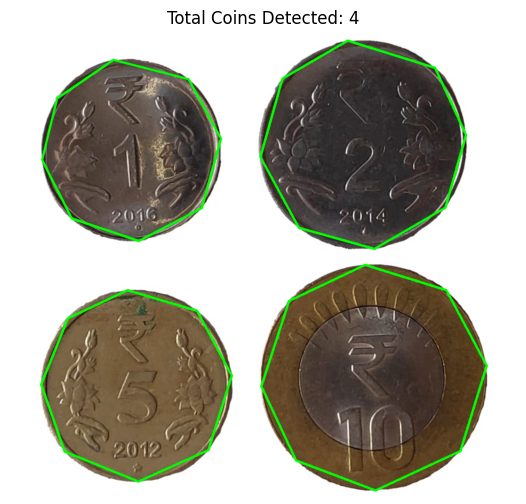

Total number of coins detected: 4


In [220]:
# Load the image
image_path = "coin.jpeg"  # Change to the actual image path
image = cv2.imread(image_path)

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply GaussianBlur to reduce noise
blurred = cv2.GaussianBlur(gray, (15, 15), 0)

# Use adaptive thresholding to detect coins
thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY_INV, 11, 2)

# Use Morphological operations to remove noise
kernel = np.ones((5,5), np.uint8)
morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

# Find contours in the processed image
contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter circular contours (coins)
num_coins = 0
for contour in contours:
    perimeter = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.02 * perimeter, True)
    area = cv2.contourArea(contour)
    
    # Ensure the shape is roughly circular and above a minimum area threshold
    if len(approx) > 5 and area > 1000:  # Minimum area filter
        circularity = 4 * np.pi * (area / (perimeter ** 2))  # Circularity measure
        if 0.7 < circularity < 1.2:  # Circular objects have circularity close to 1
            num_coins += 1
            cv2.drawContours(image, [approx], -1, (0, 255, 0), 3)  # Draw detected coins

# Convert BGR to RGB for Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display using Matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.axis("off")  # Hide axis
plt.title(f"Total Coins Detected: {num_coins}")
plt.show()

# Print total number of coins detected
print(f"Total number of coins detected: {num_coins}")
